In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [48]:
df = pd.read_json('../data/Prepared/car_data.json')

## Data contract (Data Dictionary + Validity Rules)

The dataset in `data/raw/car_data.json` and `data/Prepared/car_data.json` currently uses the same column schema. The table below documents the expected meaning, type, and validation rules for each field.

So this works as checklist when cleaning data.

| Column | Meaning | Type | Valid range/values | Units | Notes |
| --- | --- | --- | --- | --- | --- |
| `url` | listing URL | string | expected to be a valid OLX posting URL | - | should identify a posting, but duplicates are present in the current data |
| `posting_date` | date the listing was posted | date string | usually `DD.MM.YYYY`; some rows use relative text such as `Сегодня` | date | must be normalized before date parsing |
| `region` | seller region in Uzbekistan | category | 13 observed region values including `Tashkent`, `Samarkand`, `Bukhara`, `Karakalpakstan` | - | 1 missing value observed |
| `district` | district or city within a region | category | 230 observed values | - | spelling and naming normalization may be needed |
| `price` | listed sale price | numeric stored as string | positive values; observed range `10,000,000` to `2,008,972,671` | local currency | 5 missing values observed; outliers should be reviewed |
| `currency` | currency code for `price` | category | mostly `UZS` when present | ISO currency code | highly sparse in the current data; many rows are missing |
| `description` | free-text ad description | text | arbitrary seller-written text | - | noisy multilingual text; useful for NLP/features after cleaning |
| `image_url` | main image link for the ad | string | expected `http`/`https` image URL | - | optional; missing values are present |
| `seller_type` | seller classification | category | mostly `private` in observed data | - | many missing values; could later include dealer/business labels |
| `model` | vehicle model name | category/text | 720 observed values | - | may mix trims, generations, and inconsistent naming |
| `body_type` | vehicle body style | category | `Sedan`, `Hatchback`, `Station Wagon`, `SUV`, `Minivan`, `Pickup`, `Coupe`, `Convertible`, `Other` | - | appears complete in the current snapshot |
| `sale_type` | sale terms attached to the listing | multi-label text/category | values such as `Simple Sale`, `Credit`, `Installment`, `Exchange`, `Rent`, often comma-separated combinations | - | multilingual and highly inconsistent; many missing values |
| `year` | vehicle manufacture year | integer stored as string | observed range `1900` to `2025` | year | should be checked against realistic car production years |
| `mileage` | vehicle mileage | integer stored as string | observed range `0` to `10,000,000` | km | missing values and obvious outliers are possible |
| `transmission` | gearbox type | category | `Manual`, `Automatic`, `Other` | - | appears complete in the current snapshot |
| `color` | vehicle color | category | 23 observed color values such as `White`, `Black`, `Gray`, `Blue` | - | synonyms may need consolidation |
| `engine_volume` | engine size | numeric stored as string | observed range `1` to `10000` | unclear/mixed | scale is inconsistent across rows and likely needs normalization before analysis |
| `fuel_type` | fuel system | category | `Gasoline/Gas`, `Gasoline`, `Electric`, `Hybrid`, `Diesel`, `Other` | - | appears complete in the current snapshot |
| `condition` | vehicle condition | category | `Excellent`, `Good`, `Average`, `Needs Repair` | - | ordinal meaning should be preserved if encoded |
| `owners_count` | number of previous owners | ordinal category stored as string | `1`, `2`, `3`, `4+` | owners | missing values are present; `4+` is grouped rather than exact |
| `additional_options` | extra features/options listed in the ad | comma-separated text list | examples include `Customs Cleared`, `Electrical Window Lifters`, parking sensors, etc. | - | multi-valued field; multilingual, sparse, and suitable for splitting into tags |

## Data intake & first checks

### Basic intake checklist:

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47106 entries, 0 to 47105
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   url                 47106 non-null  object 
 1   posting_date        47106 non-null  object 
 2   region              47105 non-null  object 
 3   district            47105 non-null  object 
 4   price               47101 non-null  object 
 5   currency            12571 non-null  object 
 6   description         47106 non-null  object 
 7   image_url           45520 non-null  object 
 8   seller_type         39798 non-null  object 
 9   model               47047 non-null  object 
 10  body_type           47106 non-null  object 
 11  sale_type           18713 non-null  object 
 12  year                47106 non-null  int64  
 13  mileage             43818 non-null  float64
 14  transmission        47106 non-null  object 
 15  color               47106 non-null  object 
 16  engine_vo

### Uniqueness + duplicates

In [50]:
df.shape[0]

47106

In [51]:
df['url'].nunique()

46106

In [52]:
df_clean = df.drop_duplicates(subset='url', keep='first').copy()

Dublicates are found. 1000 url have same url

### Target integrity check

The target variable (price) represents seller-listed prices, which may include noise due to negotiation strategies and inconsistent reporting.

##  Data quality audit (prove what’s wrong before fixing)

Data quality audit

|Column|% missing |Is missing acceptable?|Why might it be missing?|
|---|---|---|---|
|currency|73%|No|Scraper could not identify USD currency|
|sale_type|60%|Maybe|Sales type not included in description|
|model|1%|No|Model not included in description|
|mileage|7%|Yes(moderate, manageable)|Seller may be hide high usage, older listings may not include it|
|additional_options|34%|Yes|User forgot to include or none exist|

## Cleaning strategy (not just steps-decisions)

In [53]:
df_clean.head(100)

,url,posting_date,region,district,price,currency,description,image_url,seller_type,model,...,sale_type,year,mileage,transmission,color,engine_volume,fuel_type,condition,owners_count,additional_options
0,https://olx.uz/d/obyavlenie/vaz-2103-gazda-yur...,26.04.2025,Jizzakh,Gallaaral,15000000,UZS,Mator karobka zadnimos qilingan yili 1979,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2103,...,None,1979,NaN,Manual,Red,12,Gasoline/Gas,Good,2,None
1,https://olx.uz/d/obyavlenie/vaz2105zhuguli-god...,26.04.2025,Namangan,Namangan,15000000,UZS,Торг строга укапота машина на ходу полный раб...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2105,...,Simple Sale,1982,72122.0,Manual,Green,1,Gasoline/Gas,Average,1,None
2,https://olx.uz/d/obyavlenie/juguli-21011-sotil...,26.04.2025,Khorezm,Karaul,15000000,UZS,Mashin toxlangan metan 100 lik bo 14 diska b...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,None,: 2101,...,None,1979,0.0,Manual,White,2103,Gasoline/Gas,Good,4+,None
3,https://olx.uz/d/obyavlenie/waxzod-kafolati-bi...,26.04.2025,Jizzakh,Mardzhanbulak,15000000,UZS,31029 96yil matori zor karopka zor magnitafon ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 31029,...,None,1996,560.0,Manual,White,105,Gasoline/Gas,Good,2,None
4,https://olx.uz/d/obyavlenie/mazda-626-starushk...,26.04.2025,Karakalpakstan,Kungrad,15000000,UZS,Прадаётсья на запчасти Мазда 626 старушка 1.6 ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 626,...,Simple Sale,1986,NaN,Manual,White,16,Gasoline/Gas,Needs Repair,None,"Customs Cleared, Electrical Window Lifters, Па..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,https://olx.uz/d/obyavlenie/jiguli-vaz-lada-21...,18.04.2025,Kashkadarya,Kasan,15000000,UZS,Mator 06 korobka 4tali benzin da 1996yil narxi...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2106,...,Simple Sale,1996,200000.0,Manual,White,1,Gasoline,Average,1,None
96,https://olx.uz/d/obyavlenie/zaz-40-lik-dakumen...,18.04.2025,Navoi,Navoi,15000000,UZS,запарож 40 лик айби йок балонлар янги мошина д...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 1140,...,None,1989,444444.0,Manual,White,41,Gasoline,Good,1,None
97,https://olx.uz/d/obyavlenie/prodam-zhiguli-210...,18.04.2025,Tashkent,Tashmore,15000000,UZS,Цвет-синий. В хорошем состоянии. Топливо-бензи...,None,private,: 2106,...,Simple Sale,1990,37000.0,Manual,Blue,11,Gasoline,Good,2,Security System
98,https://olx.uz/d/obyavlenie/ford-scorpio-1-pok...,18.04.2025,Tashkent,TashkentYashnabadskiy rayon,15000000,UZS,"Техническое состояние хорошее, \nВ этом году б...",https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Scorpio,...,None,1986,NaN,Manual,Red,2,Gasoline,Good,2,None


### Standardization rules (categorical)

#### Starting off with `model` column

In [54]:
df_clean['model'].unique()

array([': 2103', ': 2105', ': 2101', ': 31029', ': 626', ': 2109',
       ': 2108', ': 412', ': 2107', ': 21', ': 2106', ': 1102 Таврия',
       ': 2111', ': 2401', ': 2125 Комби', ': Tico', ': Прочее',
       ': Skyline GT-R', ': 2140', ': 469', ': 69', ': 24', ': Другая',
       ': 21109', ': 21099', ': Courier', ': 100', ': 1140', ': Scorpio',
       ': 21011', ': 21111', ': 66', ': Korando', ': 2102', ': Omega',
       ': 31', ': 3110', ': GE3', ': Ascona', ': 2121 Нива', ': 407',
       ': Largus', ': 2141', ': 21093', ': Sierra', ': 2715', ': 2110',
       ': 80', ': Matiz', ': 1117 Kalina универсал', ': 2410', ': 21013',
       ': 21124', ': Cabriolet', ': ASLK 2137', ': 3102', ': 2104',
       ': Simbir', ': Patriot', ': 21106', ': Golf', ': 968M', ': Escort',
       ': 968', ': Taunus', ': 2402', ': Fiesta', ': 21060', ': Uno',
       ': S3', ': 126', ': Sens', ': 2206', ': Jetta', ': 21051',
       ': Espero', ': 21061', ': 1118 Kalina седан', ': 401', ': Arcadia',
       ': 

The original model column contained inconsistent representations, including numeric codes, partial names, and mixed-language values. A mapping dictionary was created to standardize these into unified car names and extract brand information, improving feature quality for modeling.

In [55]:
model_to_name = {

    # LADA (VAZ)
    "2101": "Lada 2101",
    "2102": "Lada 2102",
    "2103": "Lada 2103",
    "2104": "Lada 2104",
    "2105": "Lada 2105",
    "2106": "Lada 2106",
    "2107": "Lada 2107",
    "2108": "Lada Samara 2108",
    "2109": "Lada Samara 2109",
    "21099": "Lada Samara 21099",
    "21011": "Lada 21011",
    "21013": "Lada 21013",
    "21061": "Lada 21061",
    "21063": "Lada 21063",
    "21071": "Lada 21071",
    "21073": "Lada 21073",
    "21083": "Lada Samara 21083",
    "21093": "Lada Samara 21093",
    "2121 Нива": "Lada Niva",
    "21214 Niva": "Lada Niva 21214",
    "4x4": "Lada Niva 4x4",
    "Kalina": "Lada Kalina",
    "1117 Kalina универсал": "Lada Kalina Wagon",
    "1118 Kalina седан": "Lada Kalina Sedan",
    "1119 Kalina хэтчбэк": "Lada Kalina Hatchback",
    "2110": "Lada 2110",
    "2111": "Lada 2111",
    "2112": "Lada 2112",
    "2113": "Lada 2113",
    "2114": "Lada 2114",
    "2115": "Lada 2115",
    "21124": "Lada 21124",
    "21106": "Lada 21106",

    # GAZ (Volga / UAZ style)
    "24": "GAZ 24 Volga",
    "2410": "GAZ 2410 Volga",
    "2401": "GAZ 2401",
    "2402": "GAZ 2402",
    "3102": "GAZ 3102 Volga",
    "31029": "GAZ 31029",
    "3110": "GAZ 3110",
    "3102i": "GAZ 3102i",

    # MOSKVICH / IZH
    "412": "Moskvich 412",
    "412 Э": "Moskvich 412",
    "2140": "Moskvich 2140",
    "2141": "Moskvich 2141",
    "21412": "Moskvich 21412",
    "ASLK 2140": "Moskvich 2140",
    "ASLK 2137": "Moskvich 2137",
    "2137 Kombi": "Moskvich 2137 Kombi",
    "2136 Kombi": "Moskvich 2136 Kombi",

    # DAEWOO (very important in Uzbekistan)
    "Matiz": "Daewoo Matiz",
    "Nexia": "Daewoo Nexia",
    "Damas": "Daewoo Damas",
    "Tico": "Daewoo Tico",
    "Espero": "Daewoo Espero",

    # CHEVROLET (UzAuto)
    "Lacetti": "Chevrolet Lacetti",
    "Gentra": "Chevrolet Gentra",
    "Cobalt": "Chevrolet Cobalt",
    "Spark": "Chevrolet Spark",
    "Malibu": "Chevrolet Malibu",
    "Tracker": "Chevrolet Tracker",
    "Onix": "Chevrolet Onix",
    "Captiva": "Chevrolet Captiva",

    # HYUNDAI
    "Sonata": "Hyundai Sonata",
    "Accent": "Hyundai Accent",
    "Elantra": "Hyundai Elantra",

    # KIA
    "Rio": "Kia Rio",
    "Sportage": "Kia Sportage",

    # VOLKSWAGEN
    "Passat": "Volkswagen Passat",
    "Golf": "Volkswagen Golf",
    "Golf III": "Volkswagen Golf III",
    "Golf VI": "Volkswagen Golf VI",
    "Jetta": "Volkswagen Jetta",
    "Transporter": "Volkswagen Transporter",
    "Scirocco": "Volkswagen Scirocco",

    #  NISSAN
    "Maxima": "Nissan Maxima",
    "Skyline GT-R": "Nissan Skyline GT-R",
    "Bluebird": "Nissan Bluebird",
    "R Nessa": "Nissan R'nessa",
    "Pathfinder": "Nissan Pathfinder",

    #  TOYOTA
    "Corolla": "Toyota Corolla",
    "Camry": "Toyota Camry",
    "Hiace": "Toyota Hiace",
    "Lite Ace": "Toyota LiteAce",

    #  FORD
    "Escort": "Ford Escort",
    "Fiesta": "Ford Fiesta",
    "Scorpio": "Ford Scorpio",

    # MERCEDES-BENZ
    "190": "Mercedes-Benz 190",
    "C 250": "Mercedes-Benz C250",
    "SL 320": "Mercedes-Benz SL320",

    # BMW
    "520": "BMW 520",

    # HONDA
    "Civic": "Honda Civic",

    # OPEL
    "Vectra": "Opel Vectra",
    "Omega": "Opel Omega",
    "Ascona": "Opel Ascona",
    "Rekord": "Opel Rekord",

    # FIAT
    "Uno": "Fiat Uno",
    "Croma": "Fiat Croma",

    # UAZ
    "469": "UAZ 469",
    "469Б": "UAZ 469",
    "3151": "UAZ 3151",
    "3159": "UAZ 3159",
    "3303": "UAZ 3303",
    "2206": "UAZ 2206",

    # ZAZ
    "968": "ZAZ 968",
    "968M": "ZAZ 968M",
    "1102 Таврия": "ZAZ Tavria",
    "1102": "ZAZ Tavria",
    "1111 Ока": "ZAZ Oka",

    # garbage / unknown
    "Прочее": None,
    "Другая": None,
}

In [56]:
brand_map = {

    # Daewoo
    "Tico": "Daewoo",
    "Matiz": "Daewoo",
    "Nexia": "Daewoo",
    "Damas": "Daewoo",
    "Espero": "Daewoo",

    # Chevrolet (UzAuto)
    "Lacetti": "Chevrolet",
    "Spark": "Chevrolet",
    "Cobalt": "Chevrolet",
    "Malibu": "Chevrolet",
    "Tracker": "Chevrolet",
    "Onix": "Chevrolet",
    "Gentra": "Chevrolet",
    "Captiva": "Chevrolet",

    # Volkswagen
    "Passat": "Volkswagen",
    "Golf": "Volkswagen",
    "Golf III": "Volkswagen",
    "Golf VI": "Volkswagen",
    "Jetta": "Volkswagen",
    "Transporter": "Volkswagen",
    "Scirocco": "Volkswagen",

    # Nissan
    "Maxima": "Nissan",
    "Skyline GT-R": "Nissan",
    "Bluebird": "Nissan",
    "R Nessa": "Nissan",
    "Pathfinder": "Nissan",

    # Hyundai
    "Sonata": "Hyundai",
    "Accent": "Hyundai",
    "Elantra": "Hyundai",

    # Kia
    "Rio": "Kia",
    "Sportage": "Kia",

    # Toyota
    "Corolla": "Toyota",
    "Camry": "Toyota",
    "Hiace": "Toyota",
    "Lite Ace": "Toyota",

    # Ford
    "Escort": "Ford",
    "Fiesta": "Ford",
    "Scorpio": "Ford",

    # Mercedes-Benz
    "190": "Mercedes-Benz",
    "C 250": "Mercedes-Benz",
    "SL 320": "Mercedes-Benz",

    # BMW
    "520": "BMW",

    # Opel
    "Vectra": "Opel",
    "Omega": "Opel",
    "Ascona": "Opel",
    "Rekord": "Opel",

    # Fiat
    "Uno": "Fiat",
    "Croma": "Fiat",

    # UAZ
    "469": "UAZ",
    "469Б": "UAZ",
    "3151": "UAZ",
    "3159": "UAZ",
    "3303": "UAZ",
    "2206": "UAZ",

    # ZAZ
    "968": "ZAZ",
    "968M": "ZAZ",
    "1102 Таврия": "ZAZ",
    "1102": "ZAZ",
    "1111 Ока": "ZAZ",

    # Moskvich / IZH
    "412": "Moskvich",
    "412 Э": "Moskvich",
    "2140": "Moskvich",
    "2141": "Moskvich",
    "21412": "Moskvich",
    "ASLK 2140": "Moskvich",
    "ASLK 2137": "Moskvich",
    "2137 Kombi": "Moskvich",
    "2136 Kombi": "Moskvich",

    # GAZ
    "24": "GAZ",
    "2410": "GAZ",
    "2401": "GAZ",
    "2402": "GAZ",
    "3102": "GAZ",
    "31029": "GAZ",
    "3110": "GAZ",
    "3102i": "GAZ",

    # Lada (VAZ)
    "2101": "Lada",
    "2102": "Lada",
    "2103": "Lada",
    "2104": "Lada",
    "2105": "Lada",
    "2106": "Lada",
    "2107": "Lada",
    "2108": "Lada",
    "2109": "Lada",
    "21011": "Lada",
    "21013": "Lada",
    "21051": "Lada",
    "21061": "Lada",
    "21071": "Lada",
    "21073": "Lada",
    "21083": "Lada",
    "21093": "Lada",
    "21099": "Lada",

    "2110": "Lada",
    "2111": "Lada",
    "2113": "Lada",
    "21106": "Lada",
    "21124": "Lada",

    "2121 Нива": "Lada",
    "21214 Niva": "Lada",
    "4x4": "Lada",

    "1117 Kalina универсал": "Lada",
    "1118 Kalina седан": "Lada",
    "1119 Kalina хэтчбэк": "Lada",

    # fallback garbage
    "Прочее": None,
    "Другая": None,
}

In [57]:
df_clean['model_clean'] = df_clean['model'].str.replace(":","", regex=False).str.strip()
df_clean['car_name'] = df_clean['model_clean'].map(model_to_name)

In [58]:
def assign_brand(model):
    if model.isdigit():
        num = int(model)

        if 2100 <= num <= 2199:
            return 'Lada'
        
        elif num in [24, 31, 3102, 31029, 3110]:
            return 'GAZ'
        
        elif num in [80, 100, 200, 50]:
            return 'Audi'
        
        elif num in [2140, 2141, 412]:
            return 'Moskvich'
    return None
def get_brand(model):
    model = str(model)

    brand = assign_brand(model)
    if brand:
        return brand
    
    for key in brand_map:
        if key.lower()in model.lower():
            return brand_map[key]
    return "Other"

In [59]:
df_clean["brand"] = df_clean["model_clean"].apply(get_brand)
df_clean["car_name"] = df_clean["car_name"].fillna(df_clean["model_clean"])

- `groupby()` is used to find model names to find common brands based on model names
- Not all data points are equally important — high-frequency categories contribute most to model performance.

In [60]:
df_clean.groupby('model_clean')['model_clean'].count().sort_values(ascending=False)

model_clean
Nexia        6455
Lacetti      4982
Matiz        4295
Damas        3882
Cobalt       3551
             ... 
El Camino       1
21102           1
Regata          1
Econoline       1
E 420           1
Name: model_clean, Length: 720, dtype: int64

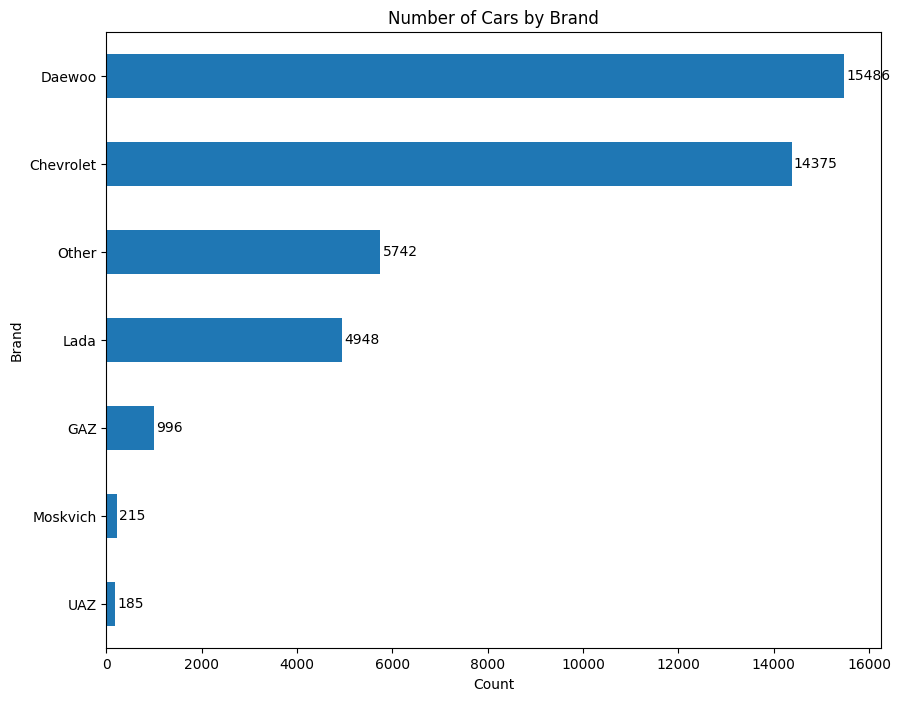

In [61]:
counts = df_clean.groupby('brand')['brand'].count().sort_values().tail(7)

ax = counts.plot(kind='barh', figsize=(10, 8))

for i, v in enumerate(counts):
    ax.text(v + 50, i, str(v), va='center')

plt.title("Number of Cars by Brand")
plt.xlabel("Count")
plt.ylabel("Brand")
plt.show()


- **What you see (facts):**  
  `Daewoo` and `Chevrolet` brands have the highest sales volume.

- **What it might mean (interpretation):**  
  These vehicles are widely available and popular in the market.  
  They can be considered **`best sellers`**, meaning they sell quickly and do not remain listed for long.

- **What you would do next (action/decision):**  
  Proceed to the next data cleaning stage.  
  Expanding brand mapping further is unlikely to significantly improve the analysis.

In [62]:
df_clean['brand'] = df_clean['brand'].fillna('Other')

In [63]:
df_clean.head()

,url,posting_date,region,district,price,currency,description,image_url,seller_type,model,...,transmission,color,engine_volume,fuel_type,condition,owners_count,additional_options,model_clean,car_name,brand
0,https://olx.uz/d/obyavlenie/vaz-2103-gazda-yur...,26.04.2025,Jizzakh,Gallaaral,15000000,UZS,Mator karobka zadnimos qilingan yili 1979,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2103,...,Manual,Red,12,Gasoline/Gas,Good,2,None,2103,Lada 2103,Lada
1,https://olx.uz/d/obyavlenie/vaz2105zhuguli-god...,26.04.2025,Namangan,Namangan,15000000,UZS,Торг строга укапота машина на ходу полный раб...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2105,...,Manual,Green,1,Gasoline/Gas,Average,1,None,2105,Lada 2105,Lada
2,https://olx.uz/d/obyavlenie/juguli-21011-sotil...,26.04.2025,Khorezm,Karaul,15000000,UZS,Mashin toxlangan metan 100 lik bo 14 diska b...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,None,: 2101,...,Manual,White,2103,Gasoline/Gas,Good,4+,None,2101,Lada 2101,Lada
3,https://olx.uz/d/obyavlenie/waxzod-kafolati-bi...,26.04.2025,Jizzakh,Mardzhanbulak,15000000,UZS,31029 96yil matori zor karopka zor magnitafon ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 31029,...,Manual,White,105,Gasoline/Gas,Good,2,None,31029,GAZ 31029,GAZ
4,https://olx.uz/d/obyavlenie/mazda-626-starushk...,26.04.2025,Karakalpakstan,Kungrad,15000000,UZS,Прадаётсья на запчасти Мазда 626 старушка 1.6 ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 626,...,Manual,White,16,Gasoline/Gas,Needs Repair,None,"Customs Cleared, Electrical Window Lifters, Па...",626,626,Other


In [64]:
df_clean = df_clean.rename(columns={"model":"model_raw"})

In [65]:
df_clean.head()

,url,posting_date,region,district,price,currency,description,image_url,seller_type,model_raw,...,transmission,color,engine_volume,fuel_type,condition,owners_count,additional_options,model_clean,car_name,brand
0,https://olx.uz/d/obyavlenie/vaz-2103-gazda-yur...,26.04.2025,Jizzakh,Gallaaral,15000000,UZS,Mator karobka zadnimos qilingan yili 1979,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2103,...,Manual,Red,12,Gasoline/Gas,Good,2,None,2103,Lada 2103,Lada
1,https://olx.uz/d/obyavlenie/vaz2105zhuguli-god...,26.04.2025,Namangan,Namangan,15000000,UZS,Торг строга укапота машина на ходу полный раб...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2105,...,Manual,Green,1,Gasoline/Gas,Average,1,None,2105,Lada 2105,Lada
2,https://olx.uz/d/obyavlenie/juguli-21011-sotil...,26.04.2025,Khorezm,Karaul,15000000,UZS,Mashin toxlangan metan 100 lik bo 14 diska b...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,None,: 2101,...,Manual,White,2103,Gasoline/Gas,Good,4+,None,2101,Lada 2101,Lada
3,https://olx.uz/d/obyavlenie/waxzod-kafolati-bi...,26.04.2025,Jizzakh,Mardzhanbulak,15000000,UZS,31029 96yil matori zor karopka zor magnitafon ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 31029,...,Manual,White,105,Gasoline/Gas,Good,2,None,31029,GAZ 31029,GAZ
4,https://olx.uz/d/obyavlenie/mazda-626-starushk...,26.04.2025,Karakalpakstan,Kungrad,15000000,UZS,Прадаётсья на запчасти Мазда 626 старушка 1.6 ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 626,...,Manual,White,16,Gasoline/Gas,Needs Repair,None,"Customs Cleared, Electrical Window Lifters, Па...",626,626,Other


In [66]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46106 entries, 0 to 47105
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   url                 46106 non-null  object 
 1   posting_date        46106 non-null  object 
 2   region              46105 non-null  object 
 3   district            46105 non-null  object 
 4   price               46101 non-null  object 
 5   currency            12262 non-null  object 
 6   description         46106 non-null  object 
 7   image_url           44547 non-null  object 
 8   seller_type         39027 non-null  object 
 9   model_raw           46047 non-null  object 
 10  body_type           46106 non-null  object 
 11  sale_type           18321 non-null  object 
 12  year                46106 non-null  int64  
 13  mileage             42857 non-null  float64
 14  transmission        46106 non-null  object 
 15  color               46106 non-null  object 
 16  engine_vo

---

#### Price & currency
- OLX uses USD currency as a default. In out data, UZS only precent but USD is missing.
- UZS will be swapped to USD to maintain consistency.

In [67]:
df_clean.groupby('currency')['currency'].count()

currency
UZS    12262
Name: currency, dtype: int64

In [68]:
df_clean['currency'] = df_clean['currency'].fillna('USD')

In [69]:
df_clean.sample(5)

,url,posting_date,region,district,price,currency,description,image_url,seller_type,model_raw,...,transmission,color,engine_volume,fuel_type,condition,owners_count,additional_options,model_clean,car_name,brand
11950,https://olx.uz/d/obyavlenie/nexia-1-god-2007-I...,29.04.2025,Tashkent,TashkentSergeliyskiy rayon,6000..,USD,Nexia 1 \nGod 2007\nPirabeg 270.000\nKraska 1 ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Nexia,...,Manual,White,1,Gasoline/Gas,Excellent,1,"Customs Cleared, Electrical Mirrors, Electrica...",Nexia,Daewoo Nexia,Daewoo
16257,https://olx.uz/d/obyavlenie/labo-oq-bez-prabeg...,11:41-01-Сегодня,Tashkent,TashkentChilanzarskiy rayon,7399..,USD,Labo 2025 yil Oq Bez Probeg Massala Yengi mosh...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Damas,...,Manual,White,1,Gasoline,Excellent,1,Customs Cleared,Damas,Daewoo Damas,Daewoo
8970,https://olx.uz/d/obyavlenie/nexia-2-arenda-vik...,29.04.2025,Tashkent,Zangiata,5100..,USD,Nexia 2 1.6 super\nYili 2010 \nMetan gaz\n ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Nexia,...,Manual,White,1600,Gasoline/Gas,Good,3,None,Nexia,Daewoo Nexia,Daewoo
9901,https://olx.uz/d/obyavlenie/neksiya-2-sotiladi...,23.04.2025,Samarkand,Samarkand,72000000,UZS,Neksiya 2 sotiladi 1.6 2009 .moshin aybi yoq i...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Nexia,...,Manual,Gray,108,Gasoline/Gas,Excellent,2,Electrical Mirrors,Nexia,Daewoo Nexia,Daewoo
43391,https://olx.uz/d/obyavlenie/zhentra-ok-abs-bor...,24.04.2025,Tashkent,TashkentYunusabadskiy rayon,17000..,USD,Жентра окелегант плюс ок АБС бор орка ойна зав...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Lacetti,...,Automatic,White,1500,Gasoline,Excellent,1,"Air Conditioner, Electrical Mirrors, Electrica...",Lacetti,Chevrolet Lacetti,Chevrolet


In [70]:
df_clean['body_type'].unique()

array(['Sedan', 'Convertible', 'Station Wagon', 'Hatchback', 'Other',
       'SUV', 'Pickup', 'Minivan', 'Coupe'], dtype=object)

In [71]:
exchange_rate = 12000

df_clean['price'] = pd.to_numeric(df_clean['price'].astype(str).str.replace(r'[^\d]', '', regex=True),
    errors='coerce'
)

df_clean['price_usd'] = df_clean['price']
df_clean.loc[df_clean['currency'] == 'UZS', 'price_usd'] = (
    df_clean.loc[df_clean['currency'] == 'UZS', 'price_usd'] / exchange_rate
).round(1)

`Currency` is now correctly formatted. Its ready for ml.

In [72]:
df_clean = df_clean.rename(columns={"price":"price_raw"})

In [73]:
df_clean.head()

,url,posting_date,region,district,price_raw,currency,description,image_url,seller_type,model_raw,...,color,engine_volume,fuel_type,condition,owners_count,additional_options,model_clean,car_name,brand,price_usd
0,https://olx.uz/d/obyavlenie/vaz-2103-gazda-yur...,26.04.2025,Jizzakh,Gallaaral,15000000.0,UZS,Mator karobka zadnimos qilingan yili 1979,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2103,...,Red,12,Gasoline/Gas,Good,2,None,2103,Lada 2103,Lada,1250.0
1,https://olx.uz/d/obyavlenie/vaz2105zhuguli-god...,26.04.2025,Namangan,Namangan,15000000.0,UZS,Торг строга укапота машина на ходу полный раб...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2105,...,Green,1,Gasoline/Gas,Average,1,None,2105,Lada 2105,Lada,1250.0
2,https://olx.uz/d/obyavlenie/juguli-21011-sotil...,26.04.2025,Khorezm,Karaul,15000000.0,UZS,Mashin toxlangan metan 100 lik bo 14 diska b...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,None,: 2101,...,White,2103,Gasoline/Gas,Good,4+,None,2101,Lada 2101,Lada,1250.0
3,https://olx.uz/d/obyavlenie/waxzod-kafolati-bi...,26.04.2025,Jizzakh,Mardzhanbulak,15000000.0,UZS,31029 96yil matori zor karopka zor magnitafon ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 31029,...,White,105,Gasoline/Gas,Good,2,None,31029,GAZ 31029,GAZ,1250.0
4,https://olx.uz/d/obyavlenie/mazda-626-starushk...,26.04.2025,Karakalpakstan,Kungrad,15000000.0,UZS,Прадаётсья на запчасти Мазда 626 старушка 1.6 ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 626,...,White,16,Gasoline/Gas,Needs Repair,None,"Customs Cleared, Electrical Window Lifters, Па...",626,626,Other,1250.0


---
#### mileage 


In [74]:
df['mileage'].describe()

count    4.381800e+04
mean     1.936853e+05
std      6.834135e+05
min      0.000000e+00
25%      3.500000e+02
50%      7.100000e+04
75%      2.030000e+05
max      1.000000e+07
Name: mileage, dtype: float64

In [75]:
df_clean["mileage"].sort_values(ascending=False)


7981     10000000.0
2254     10000000.0
2420     10000000.0
25087    10000000.0
24073    10000000.0
            ...    
47086           NaN
47087           NaN
47088           NaN
47091           NaN
47092           NaN
Name: mileage, Length: 46106, dtype: float64

That was the wildest part of the cleaning. `mileage` column has serius outliers / dirty values.

In [76]:
df_clean['mileage_raw'] = df_clean['mileage']
df_clean.loc[df_clean['mileage'] > 500000, 'mileage'] = np.nan

In [77]:
df_clean.sample(6)

,url,posting_date,region,district,price_raw,currency,description,image_url,seller_type,model_raw,...,engine_volume,fuel_type,condition,owners_count,additional_options,model_clean,car_name,brand,price_usd,mileage_raw
20492,https://olx.uz/d/obyavlenie/srchono-prodaetsya...,09.04.2025,Tashkent,TashkentMirzo-Ulugbekskiy rayon,8300.0,USD,Продается chevrolet nexia 3. Год выпуска 2019г...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Nexia,...,1500,Gasoline,Good,1,"Security System, Electrical Mirrors, Customs C...",Nexia,Daewoo Nexia,Daewoo,8300.0,86000.0
33091,https://olx.uz/d/obyavlenie/kobalt-4-pozisiya-...,17.04.2025,Navoi,Navoi,162200000.0,UZS,"Kobalt 4 pozisiya sotiladi, 2024 yilda ishlab ...",https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Cobalt,...,15,Gasoline,Excellent,1,"Customs Cleared, Electrical Mirrors, Electrica...",Cobalt,Chevrolet Cobalt,Chevrolet,13516.7,8000.0
32112,https://olx.uz/d/obyavlenie/srochni-sotiladi-I...,12.05.2025,Tashkent,TashkentChilanzarskiy rayon,8600.0,USD,Bankdan olingan \nNarxini keliwtrib beraman \n...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Spark,...,125,Gasoline,Good,1,"Air Conditioner, Electrical Window Lifters",Spark,Chevrolet Spark,Chevrolet,8600.0,240000.0
31498,https://olx.uz/d/obyavlenie/damas-sotiladi-202...,26.04.2025,Samarkand,Samarkand,8500.0,USD,Assalomu alaykum damas sotiladi 2023-yil probe...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Damas,...,8,Gasoline/Gas,Good,1,None,Damas,Daewoo Damas,Daewoo,8500.0,35000.0
31876,https://olx.uz/d/obyavlenie/chevrolet-cobalt-m...,10.05.2025,Tashkent,TashkentYunusabadskiy rayon,113711000.0,UZS,Assalomu aleykum aziz vatandoshlar\nEndilikda ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,None,: Cobalt,...,1485,Gasoline,Excellent,None,"Electrical Window Lifters, Air Conditioner",Cobalt,Chevrolet Cobalt,Chevrolet,9475.9,0.0
14309,https://olx.uz/d/obyavlenie/narxini-kelishamiz...,12.04.2025,Kashkadarya,Dehkanabad,90000000.0,UZS,Moshinani holati ideal \nFaqat bir qoʻlda mini...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Damas,...,8,Gasoline/Gas,Excellent,None,None,Damas,Daewoo Damas,Daewoo,7500.0,131850.0


In [78]:
df_clean['mileage'].isna().sum()

5108

In [79]:
df_clean.loc[
    df_clean["mileage"] == 0,
    ["car_name", "year", "mileage", "price_raw", "description"]
]


,car_name,year,mileage,price_raw,description
2,Lada 2101,1979,0.0,15000000.0,Mashin toxlangan metan 100 lik bo 14 diska b...
18,GAZ 2401,1983,0.0,15000000.0,Волга газ 2401 сотилади матор килинди \nапкатк...
32,69,1982,0.0,15000000.0,Мошина ранги яашил матор килинса болди йуради ...
40,Lada 2106,1988,0.0,15000000.0,Prapanda moshina elektirkka kursatish kerak k...
65,Lada 2105,1983,0.0,15000000.0,Moshinani xarajati yoq mayda chuyda ozmoz ishi...
...,...,...,...,...,...
47089,Chazor,2024,0.0,302300000.0,Предлагаем вашему вниманию от BYD AUTOZONE (Лу...
47090,Chazor,2024,0.0,302300000.0,BYD Chazor dm-i гибрид 3 -4 позициялари бо...
47093,C11 EV,2025,0.0,301600000.0,Год выпуска - 2025 г.в.\nЗапас хода - NEDC - 4...
47096,Chevrolet Tracker,2023,0.0,23200.0,"Tracker 2, 2-pozitsiya avtomat, bez probeg so..."


- By looking at the results, a few insights were obtained:
    - Almost all old cars have mileage equal to 0, meaning the owners do not know the mileage count so they didn't specify it.
    - Maybe we will decide the mileage based on price and year.


In [80]:
df_clean.loc[(df_clean['mileage'] < 5000) & (df_clean['price_usd'] < 10000) & (df_clean['year'] < 2023), 'mileage'] = np.nan

This code is based on pure logic. If a car is old and mileage is too low than its not real. If a price also low that it indicates the car is used so those will be marked as missing.

In [81]:
df_clean.loc[(df_clean['mileage'] == 0) &
    (df_clean['year'] < 2024),
    'mileage'
] = np.nan

In [93]:
df_clean['mileage_log'] = np.log1p(df_clean['mileage'])


In [94]:
df_clean['mileage_group'] = pd.cut(
    df_clean['mileage'],
    bins=[-1, 15000, 50000, 100000, 200000, 500000],
    labels=['new_or_very_low', 'low', 'medium', 'high', 'very_high']
)


SO We know 

In [85]:
df_clean['mileage'].describe()

count     35346.000000
mean     126926.272591
std      125928.582811
min           0.000000
25%       11111.000000
50%       93000.000000
75%      206000.000000
max      500000.000000
Name: mileage, dtype: float64

#### engine_volume

In [86]:
df_clean['engine_volume'].value_counts()

engine_volume
1       10978
1500     4703
15       4666
16       2405
2        2089
        ...  
234         1
752         1
1895        1
628         1
1479        1
Name: count, Length: 779, dtype: int64

In [106]:
df_clean.loc[df_clean['engine_volume'] == 8, ['model_raw', 'year', 'engine_volume']]


,model_raw,year,engine_volume
116,: Tico,1999,8
197,: 2125 Комби,1988,8
314,: Tico,1996,8
552,: Tico,1997,8
565,: Tico,1998,8
...,...,...,...
44254,: Yuan Up,2025,8
44680,: Tracker,2023,8
44801,: Tracker,2023,8
46852,: Прочее,2022,8


Results suggest values in engine_volume mostly are incorrect. The data still contains noise. Some sellers put model id in engine_volume.


In [88]:
df_clean.loc[df_clean['engine_volume'] == 125]

,url,posting_date,region,district,price_raw,currency,description,image_url,seller_type,model_raw,...,condition,owners_count,additional_options,model_clean,car_name,brand,price_usd,mileage_raw,mileage_log,mileage_group
1245,https://olx.uz/d/obyavlenie/moskvich-21-41-mos...,06.04.2025,Tashkent,Chirchik,1500.0,USD,Москвич 2141 \n1990 г\nКелишамиз. Краска килин...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2141,...,Average,1,Парктроник,2141,Moskvich 2141,Lada,1500.0,1000.0,NaN,NaN
1802,https://olx.uz/d/obyavlenie/06-jguli-sotiladi-...,21.04.2025,Navoi,Navoi,18000000.0,UZS,Metan o‘rnatilgan \nXarajati yo‘q\nHolati yaxshi,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2106,...,Good,1,None,2106,Lada 2106,Lada,1500.0,333333.0,12.716900,very_high
1891,https://olx.uz/d/obyavlenie/zur-xolat-ala-ID3A...,25.04.2025,Samarkand,Dzhuma,21000000.0,UZS,Xolat. Yaxshi. Rurshi. Idal motor. Moy. Yemad...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,None,: 2106,...,Good,1,None,2106,Lada 2106,Lada,1750.0,NaN,NaN,NaN
2176,https://olx.uz/d/obyavlenie/gaz-3110-soltiladi...,08.04.2025,Bukhara,Buhara,20000000.0,UZS,Metan gaz bor 3 pakaleni. Kuzuvida ishlari bor...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 3110,...,Average,2,"Electrical Mirrors, Electrical Window Lifters,...",3110,GAZ 3110,GAZ,1666.7,300000.0,12.611541,very_high
3486,https://olx.uz/d/obyavlenie/moskvich-407-otlic...,28.04.2025,Bukhara,Buhara,25000000.0,UZS,Москвич 407 идеальный состояние 90 413 92 00,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 407,...,Excellent,1,Customs Cleared,407,407,Other,2083.3,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44014,https://olx.uz/d/obyavlenie/trecker-2-premier-...,06.05.2025,Khorezm,Pitnak,234000000.0,UZS,Xolati a'lo 2021 yil kareyski variant barcha m...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,None,: Tracker,...,Excellent,2,"Парктроник, Electrical Mirrors, Customs Cleare...",Tracker,Chevrolet Tracker,Chevrolet,19500.0,76000.0,11.238502,medium
44389,https://olx.uz/d/obyavlenie/tracker-2-primier-...,02.05.2025,Tashkent,TashkentUchtepinskiy rayon,19000.0,USD,Tracker 2 primier мошина топ тоза . Битта ко...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Tracker,...,Excellent,1,"Air Conditioner, Customs Cleared, Electrical M...",Tracker,Chevrolet Tracker,Chevrolet,19000.0,17000.0,9.741027,low
45220,https://olx.uz/d/obyavlenie/1-yil-kafolat-bera...,09.05.2025,Bukhara,Galaasiya,250000000.0,UZS,Автомашина 2021 йилда ишлаб чикарилган 57 минг...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Caddy,...,Excellent,1,None,Caddy,Caddy,Other,20833.3,57000.0,10.950824,medium
45659,https://olx.uz/d/obyavlenie/tracker-2-ltz-sht-...,02.05.2025,Khorezm,Urgench,263000000.0,UZS,Tracker 2 LTZ shòt 2023 yil nomer olinmagan òz...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Tracker,...,Excellent,1,"Парктроник, Electrical Mirrors, Customs Cleare...",Tracker,Chevrolet Tracker,Chevrolet,21916.7,0.0,NaN,NaN


In [89]:

df_clean['engine_volume_raw'] = df_clean['engine_volume']

def format_engine_value(x):
    if pd.isna(x):
        return np.nan
    if x >= 1000:
        return x / 1000
    if 100 <= x < 1000:
        return x / 100
    if 10 <= x < 100:
        return x / 10
    if 0 < x < 10:
        return x
    return np.nan
df_clean['engine_volume_l'] = df_clean['engine_volume_raw'].apply(format_engine_value)


In [107]:
df_clean["engine_volume_l"].value_counts().sort_index()


engine_volume_l
1.00    11653
1.01        9
1.02       40
1.03       29
1.04       11
        ...  
5.80       13
5.85        1
5.87        1
5.90        5
6.00      360
Name: count, Length: 282, dtype: int64

- Removed incorrect range

In [91]:
df_clean.loc[
    (df_clean['engine_volume_l'] < 0.6) | (df_clean['engine_volume_l'] > 6),
    'engine_volume_l'
] = np.nan

In [109]:
df_clean.sample(5)

,url,posting_date,region,district,price_raw,currency,description,image_url,seller_type,model_raw,...,additional_options,model_clean,car_name,brand,price_usd,mileage_raw,mileage_log,mileage_group,engine_volume_raw,engine_volume_l
30211,https://olx.uz/d/obyavlenie/nexia-3-2019-oq-at...,22.04.2025,Tashkent,TashkentSergeliyskiy rayon,12300.0,USD,"ASIA AVTO saloni sizga \nAvto kredit, Treding,...",https://frankfurt.apollo.olxcdn.com:443/v1/fil...,None,: Nexia,...,None,Nexia,Daewoo Nexia,Daewoo,12300.0,34000.0,10.434145,low,15,1.5
37432,https://olx.uz/d/obyavlenie/chevrolet-cobalt-I...,21.04.2025,Navoi,Navoi,172000000.0,UZS,Yangidek xolatda turbdi,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Cobalt,...,None,Cobalt,Chevrolet Cobalt,Chevrolet,14333.3,20.0,3.044522,new_or_very_low,1,1.0
25436,https://olx.uz/d/obyavlenie/prodaetsya-damas-2...,17.04.2025,Tashkent,TashkentBektemirskiy rayon,55000000.0,UZS,Продаётся машина дамас в нормальном состоянии ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Damas,...,None,Damas,Daewoo Damas,Daewoo,4583.3,NaN,NaN,NaN,8,NaN
33437,https://olx.uz/d/obyavlenie/cobalt-2020-yil-pr...,27.04.2025,Namangan,Pap,12500.0,USD,Chevrolet Cobalt 2020 yil 41000 km yurgani hal...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,None,: Cobalt,...,"Air Conditioner, Security System, Electrical W...",Cobalt,Chevrolet Cobalt,Chevrolet,12500.0,41000.0,10.621352,low,1500,1.5
28485,https://olx.uz/d/obyavlenie/tez-va-arzon-sotil...,08.04.2025,Bukhara,Buhara,5000.0,USD,Holati zo'r kam yurigan luks kansaner 2007-yil...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Nexia,...,"Air Conditioner, Electrical Mirrors, Парктрони...",Nexia,Daewoo Nexia,Daewoo,5000.0,110.0,NaN,NaN,15,1.5


In [ ]:
df_clean['engine_volume_l'] = df_clean['engine_volume_l'].round(2)

#### Date cleaning


In [111]:
df_clean.sample(5)

,url,posting_date,region,district,price_raw,currency,description,image_url,seller_type,model_raw,...,additional_options,model_clean,car_name,brand,price_usd,mileage_raw,mileage_log,mileage_group,engine_volume_raw,engine_volume_l
14296,https://olx.uz/d/obyavlenie/chevrolet-damas-2-...,14.04.2025,Kashkadarya,Guzar,90000000.0,UZS,Damas sotiladi yili 2020 probeg 98 ming narxi ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Damas,...,None,Damas,Daewoo Damas,Daewoo,7500.0,98000.0,11.492733,medium,1,1.0
33305,https://olx.uz/d/obyavlenie/cobalt-sotiladi-ID...,06.05.2025,Tashkent,Angren,12500.0,USD,Cobalt AT sotiladi 2022-yil. 70000 probeg 908 ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Cobalt,...,"Security System, Electrical Mirrors, Electrica...",Cobalt,Chevrolet Cobalt,Chevrolet,12500.0,70000.0,11.156265,medium,1500,1.5
12737,https://olx.uz/d/obyavlenie/damas-2020-yil-sot...,16.04.2025,Bukhara,Gizhduvan,6200.0,USD,Damas sotiladi xolati yaxshi. Kraskasi toza ur...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Damas,...,None,Damas,Daewoo Damas,Daewoo,6200.0,2000000.0,NaN,NaN,4,4.0
18725,https://olx.uz/d/obyavlenie/prodayu-avtomobil-...,01.05.2025,Kashkadarya,Karshi,100000000.0,UZS,"Продается автомобиль Mercedes Vito, 2006 год ...",https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Vito,...,Customs Cleared,Vito,Vito,Other,8333.3,NaN,NaN,NaN,300,3.0
8079,https://olx.uz/d/obyavlenie/prodaetsya-vaz-210...,03.04.2025,Tashkent,TashkentYakkasarayskiy rayon,3000.0,USD,Продается ваз 2107 в отличном состоянии расход...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2107,...,Electrical Window Lifters,2107,Lada 2107,Lada,3000.0,NaN,NaN,NaN,1,1.0


After inspecting posting_date column, I realized the posting dates in that column is not actually original posting date. Based on my research, Sellers can actually refresh the posting so that their car stays at the top. So this column is not useful for analysis. So i will delete it later on.

In [ ]:
df_clean = df_clean.drop(columns=['posting_date'])

#### sale_type cleaning process

In [114]:
df_clean['seller_type'].value_counts()

seller_type
private    39027
Name: count, dtype: int64

The result shows that seller_type only carries one value that is "private" there? There is no meaning to keep this column so I will drop this column.

In [118]:
df_clean = df_clean.drop(columns=['seller_type'])

In [119]:
df_clean.columns

Index(['url', 'region', 'district', 'price_raw', 'currency', 'description',
       'image_url', 'model_raw', 'body_type', 'sale_type', 'year', 'mileage',
       'transmission', 'color', 'engine_volume', 'fuel_type', 'condition',
       'owners_count', 'additional_options', 'model_clean', 'car_name',
       'brand', 'price_usd', 'mileage_raw', 'mileage_log', 'mileage_group',
       'engine_volume_raw', 'engine_volume_l'],
      dtype='object')

#### owners_count cleaning process

In [120]:
df_clean['owners_count'].value_counts()

owners_count
1     28211
2     10191
3      1905
4+     1060
Name: count, dtype: int64

We should change the column type.

In [125]:
def format_owners_count(x):
    if pd.isna(x):
        return np.nan
    x = str(x)
    x = x.strip('+')
    return float(x)

df_clean['owners_count'] = df_clean['owners_count'].apply(format_owners_count)
df_clean['owners_count'] = df_clean['owners_count'].astype('Int64')

In [126]:
df_clean.head()

,url,region,district,price_raw,currency,description,image_url,model_raw,body_type,sale_type,...,additional_options,model_clean,car_name,brand,price_usd,mileage_raw,mileage_log,mileage_group,engine_volume_raw,engine_volume_l
0,https://olx.uz/d/obyavlenie/vaz-2103-gazda-yur...,Jizzakh,Gallaaral,15000000.0,UZS,Mator karobka zadnimos qilingan yili 1979,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 2103,Sedan,None,...,None,2103,Lada 2103,Lada,1250.0,NaN,NaN,NaN,12,1.20
1,https://olx.uz/d/obyavlenie/vaz2105zhuguli-god...,Namangan,Namangan,15000000.0,UZS,Торг строга укапота машина на ходу полный раб...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 2105,Sedan,Simple Sale,...,None,2105,Lada 2105,Lada,1250.0,72122.0,11.186128,medium,1,1.00
2,https://olx.uz/d/obyavlenie/juguli-21011-sotil...,Khorezm,Karaul,15000000.0,UZS,Mashin toxlangan metan 100 lik bo 14 diska b...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 2101,Convertible,None,...,None,2101,Lada 2101,Lada,1250.0,0.0,NaN,NaN,2103,2.10
3,https://olx.uz/d/obyavlenie/waxzod-kafolati-bi...,Jizzakh,Mardzhanbulak,15000000.0,UZS,31029 96yil matori zor karopka zor magnitafon ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 31029,Station Wagon,None,...,None,31029,GAZ 31029,GAZ,1250.0,560.0,NaN,NaN,105,1.05
4,https://olx.uz/d/obyavlenie/mazda-626-starushk...,Karakalpakstan,Kungrad,15000000.0,UZS,Прадаётсья на запчасти Мазда 626 старушка 1.6 ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 626,Hatchback,Simple Sale,...,"Customs Cleared, Electrical Window Lifters, Па...",626,626,Other,1250.0,NaN,NaN,NaN,16,1.60


#### sale_type cleaning process

In [129]:
df_clean['sale_type'].value_counts()

sale_type
Simple Sale                                                                     13562
Простая продажа, Рассрочка                                                        513
Простая продажа, Кредит                                                           385
Exchange                                                                          360
Простая продажа, Возможен обмен                                                   339
                                                                                ...  
Простая продажа, Кредит, Рассрочка, Аренда, Возможен обмен                          1
Лизинг, Рассрочка, Кредит, Аренда                                                   1
Простая продажа, Кредит, Лизинг, Рассрочка, Аренда, Возможен обмен, Trade-in        1
Возможен обмен, Лизинг, Trade-in, Аренда, Кредит, Простая продажа                   1
Аренда, Возможен обмен, Кредит                                                      1
Name: count, Length: 345, dtype: int64

In [ ]:
Translate_list = {
    "Кредит": "Credit",
    "Рассрочка": "Installment plan",
    "Простая продажа": "Direct sale",
    "Возможен обмен": "Exchange possible",
    "Аренда": "Rent",
    "Лизинг": "Leasing"
}

def translate(text):
    if pd.isna(text):
        return text
    
    items = [item.strip() for item in text.split(",")]
    translated = [Translate_list.get(item, item) for item in items]
    
    return ", ".join(translated)

df_clean["sale_type"] = df_clean["sale_type"].apply(translate)


In [137]:
df_clean.sample(10)

,url,region,district,price_raw,currency,description,image_url,model_raw,body_type,sale_type,...,model_clean,car_name,brand,price_usd,mileage_raw,mileage_log,mileage_group,engine_volume_raw,engine_volume_l,sale_type_raw
15016,https://olx.uz/d/obyavlenie/nexia-2-yili-2010-...,Tashkent,Angren,7000.0,USD,Nexia 2 rangi qora metan gazi bor 100 tali 4 ...,None,: Nexia,Other,None,...,Nexia,Daewoo Nexia,Daewoo,7000.0,134.0,NaN,NaN,1,1.00,None
1079,https://olx.uz/d/obyavlenie/moskvich-412-uzimn...,Tashkent,Charvak,1200.0,USD,Москвич сотаман без посредник.Холати зор.суяги...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 412 Э,Sedan,None,...,412 Э,Moskvich 412,Moskvich,1200.0,100000.0,11.512935,medium,16,1.60,None
20584,https://olx.uz/d/obyavlenie/neksiya-2-gibrid-I...,Tashkent,Keles,8300.0,USD,Нексия 2. Гибрид. 2015 г.. 153000 пробег. Конд...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: Nexia,Sedan,None,...,Nexia,Daewoo Nexia,Daewoo,8300.0,153000.0,11.938200,high,1,1.00,None
30161,https://olx.uz/d/obyavlenie/holati-a-lo-pul-ke...,Bukhara,Buhara,12300.0,USD,Холатига гапйу́к краска тоза орка бампурига кр...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: Cobalt,Sedan,None,...,Cobalt,Chevrolet Cobalt,Chevrolet,12300.0,60000.0,11.002117,medium,105,1.05,None
18633,https://olx.uz/d/obyavlenie/nexia-3-2-pozitsiy...,Kashkadarya,Karshi,100000000.0,UZS,2018 yil Nexia 3 mehanika sotiladi. Probeg:895...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: Nexia,Sedan,"Credit, Direct sale",...,Nexia,Daewoo Nexia,Daewoo,8333.3,89500.0,11.402005,medium,1500,1.50,"Кредит, Простая продажа"
15170,https://olx.uz/d/obyavlenie/prodam-epica-v-otl...,Tashkent,TashkentBektemirskiy rayon,7000.0,USD,"Продам свою машину Эпику, одни руки, машина ух...",https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: Epica,Sedan,None,...,Epica,Epica,Other,7000.0,252000.0,12.437188,very_high,2400,2.40,None
14299,https://olx.uz/d/obyavlenie/vaz-2121-niva-4x4-...,Jizzakh,Dzhizak,90000000.0,UZS,Бартир хам бор ласетига. Кузов кайта жихозланг...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 4x4,SUV,Exchange,...,4x4,Lada Niva 4x4,Lada,7500.0,12000.0,9.392745,new_or_very_low,108,1.08,Exchange
7645,https://olx.uz/d/obyavlenie/neksiya-tez-sotila...,Bukhara,Shafirkan,2800.0,USD,Tez sotiladi metani bor akultorlari yangi,None,: Nexia,Sedan,Simple Sale,...,Nexia,Daewoo Nexia,Daewoo,2800.0,450000.0,13.017005,very_high,15,1.50,Simple Sale
1831,https://olx.uz/d/obyavlenie/vaz-2106-sariq-saf...,Samarkand,Bulungur,1600.0,USD,To‘liq Vaz 2106\n1996-yil Sariq-safari. \nMeji...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 2106,Sedan,Simple Sale,...,2106,Lada 2106,Lada,1600.0,NaN,NaN,NaN,1600,1.60,Simple Sale
28288,https://olx.uz/d/obyavlenie/prodam-samsung-sm5...,Tashkent,TashkentMirzo-Ulugbekskiy rayon,5000.0,USD,Продам samsung sm-5 дубликат nissan maxima дву...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: Maxima,Sedan,Simple Sale,...,Maxima,Nissan Maxima,Nissan,5000.0,180000.0,12.100718,high,2,2.00,Simple Sale


- `sales_type` column translated
- added back up
- didnt fill `sales_type` column with unknown inorder to avoid extra rows in new table